This is a **very important step in ray tracing**:
👉 *nested dielectrics (hollow glass / air bubble inside glass)*

It is where most beginners finally understand why `ri = 1.0 / n` matters.

---

# 1. Physical idea (what we are building)

We simulate:

### Hollow glass sphere:

* Outer sphere → glass shell
* Inner sphere → air bubble
* Light path:

$$
air \rightarrow glass \rightarrow air \rightarrow glass \rightarrow air
$$

So the ray refracts **twice per boundary**.

---

# 2. Key concept: relative refractive index

Dielectric uses:

$$
ri = \frac{\eta_{inside}}{\eta_{outside}}
$$

So we can model nested materials easily.

---

# 3. Material setup (C++ mapping)

| Object       | Meaning     | η (effective) |
| ------------ | ----------- | ------------- |
| outer sphere | glass shell | 1.50          |
| inner sphere | air bubble  | 1.00 / 1.50   |

---

# 4. Geometry table

| Sphere | Radius | Role           |
| ------ | ------ | -------------- |
| outer  | 0.5    | glass boundary |
| inner  | 0.4    | hollow cavity  |

---

# 5. IMPORTANT INTUITION

This is NOT two objects randomly overlapping.

Instead:

> Inner sphere “subtracts” glass → creates hollow region

Ray experiences:

* enter glass
* enter air
* exit air
* exit glass

---

# 6. FULL PYTHON CODE (correct translation)

```python id="h8k2lz"
from util.vec3 import Vec3, Color, Point3

from util.metal.lambertian import Lambertian
from util.metal.metal import Metal
from util.metal.dielectric import Dielectric
from util.metal.sphere import Sphere
from util.metal.hittable_list import HittableList
from util.metal.camera import Camera


# ==========================================
# WORLD
# ==========================================
world = HittableList()


# ==========================================
# MATERIALS
# ==========================================

# ground (diffuse)
material_ground = Lambertian(Color(0.8, 0.8, 0.0))

# center sphere (diffuse)
material_center = Lambertian(Color(0.1, 0.2, 0.5))

# glass shell (outer sphere)
# CHANGE: normal glass refraction
material_left = Dielectric(1.50)

# hollow air bubble (inner sphere)
# CHANGE: inverse ratio (air inside glass)
material_bubble = Dielectric(1.0 / 1.50)

# metal sphere
material_right = Metal(Color(0.8, 0.6, 0.2), 0.0)


# ==========================================
# SCENE OBJECTS
# ==========================================

# ground plane (big sphere trick)
world.add(
    Sphere(Point3(0.0, -100.5, -1.0), 100.0, material_ground)
)

# center diffuse sphere
world.add(
    Sphere(Point3(0.0, 0.0, -1.2), 0.5, material_center)
)

# ==========================================
# HOLLOW GLASS SPHERE (IMPORTANT PART)
# ==========================================

# OUTER GLASS SHELL
world.add(
    Sphere(Point3(-1.0, 0.0, -1.0), 0.5, material_left)
)

# INNER AIR BUBBLE
# CHANGE: same center, smaller radius
world.add(
    Sphere(Point3(-1.0, 0.0, -1.0), 0.4, material_bubble)
)

# metal sphere
world.add(
    Sphere(Point3(1.0, 0.0, -1.0), 0.5, material_right)
)


# ==========================================
# CAMERA
# ==========================================
cam = Camera()
cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400

# CHANGE: better sampling for glass stability
cam.samples_per_pixel = 100
cam.max_depth = 50


# ==========================================
# RENDER
# ==========================================
cam.render(world)
```

---

# 7. STEP-BY-STEP BEHAVIOR OF RAY

| Stage | Medium transition    | Action              |
| ----- | -------------------- | ------------------- |
| 1     | air → glass          | refraction          |
| 2     | glass → air (bubble) | stronger refraction |
| 3     | air → glass          | exit bubble         |
| 4     | glass → air          | exit outer shell    |

---

# 8. WHAT CHANGED vs normal sphere

## ❌ Single dielectric sphere:

* only 2 boundary interactions
* simple lens effect

---

## ✔ Hollow sphere:

* 4 refractions
* internal inversion
* stronger distortion
* “real glass thickness” effect

---

# 9. WHY inner sphere is inverted index

This is key:

```python id="r9k2qz"
1.0 / 1.50
```

Because:

| Region             | η relation        |
| ------------------ | ----------------- |
| glass → air        | normal refraction |
| glass → hollow air | reversed ratio    |

---

# 10. VISUAL RESULT

You should now see:

### Left object (hollow glass sphere):

* thick glass rim
* double refraction
* stronger lensing
* visible “shell depth”

---

# 11. KEY INTUITION (VERY IMPORTANT)

> A hollow glass sphere is NOT a new material
> It is just **two overlapping dielectric boundaries**

---

# 12. If you want next upgrade

I can show you:

### 👉 1. Correct nested medium tracking (real production ray tracer)

### 👉 2. Preventing “inside-out normal bugs”

### 👉 3. Full physically based glass pipeline (Blender / Unreal style)

### 👉 4. How real engines handle nested dielectrics (very important)

Just say 👍


In [1]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

In [2]:
from util.material import Material
from util.ray import Ray
from util.vec3 import Vec3, reflect, unit_vector, random_unit_vector, dot
class Metal(Material):
    def __init__(self, albedo, fuzz=0.0):
        # metal color
        self.albedo = albedo

        # surface roughness (0 = perfect mirror, 1 = very rough)
        self.fuzz = min(fuzz, 1.0)

    def scatter(self, r_in, rec):

        # ==========================================
        # STEP 1: normalize incoming ray direction
        # ==========================================
        unit_dir = unit_vector(r_in.direction())

        # ==========================================
        # STEP 2: perfect reflection direction
        # R = V - 2(V·N)N
        # ==========================================
        reflected = reflect(unit_dir, rec.normal)

        # ==========================================
        # STEP 3: add fuzz (surface imperfection)
        # ==========================================
        scattered_dir = reflected + self.fuzz * random_unit_vector()

        # ==========================================
        # STEP 4: build scattered ray
        # ==========================================
        scattered = Ray(rec.p, scattered_dir)

        # ==========================================
        # STEP 5: energy attenuation (metal tint)
        # ==========================================
        attenuation = self.albedo

        # ==========================================
        # MUST return exactly 2 values
        # ==========================================
        return scattered, attenuation

In [3]:
import math
from util.ray import Ray
from util.vec3 import Vec3, unit_vector, dot


def refract(uv, n, etai_over_etat):
    """
    Vector refraction based on Snell's Law.

    uv : unit incident direction
    n  : surface normal
    etai_over_etat : ratio of refractive indices (η / η')
    """

    # ==========================================
    # STEP 1: cos(theta)
    # cosθ = min(-uv · n, 1)
    # ==========================================
    cos_theta = min(dot(-uv, n), 1.0)

    # ==========================================
    # STEP 2: perpendicular component
    # R⊥ = (η/η') (uv + cosθ n)
    # ==========================================
    r_out_perp = (uv + n * cos_theta) * etai_over_etat

    # ==========================================
    # STEP 3: parallel component
    # R∥ = -sqrt(1 - |R⊥|²) n
    # ==========================================
    r_out_parallel = n * (-math.sqrt(abs(1.0 - r_out_perp.length_squared())))

    # ==========================================
    # STEP 4: final refracted direction
    # ==========================================
    return r_out_perp + r_out_parallel

In [4]:
import math
import random

from util.ray import Ray
from util.vec3 import Vec3, unit_vector, dot, reflect


class Dielectric:
    def __init__(self, refraction_index):
        # η (eta): refractive index of material (glass ~1.5)
        self.refraction_index = refraction_index

    # ==========================================
    # SCHLICK APPROXIMATION (Fresnel reflectance)
    # ==========================================
    def reflectance(self, cosine, ref_idx):

        # STEP 1: compute base reflectivity R0
        # CHANGE: replaces full Fresnel equations
        r0 = (1 - ref_idx) / (1 + ref_idx)
        r0 = r0 * r0

        # STEP 2: angle-based adjustment
        # (1 - cosθ)^5 makes grazing angles highly reflective
        return r0 + (1 - r0) * pow((1 - cosine), 5)

    def scatter(self, r_in, rec):

        # ==========================================
        # STEP 1: no absorption in glass
        # ==========================================
        attenuation = Vec3(1.0, 1.0, 1.0)

        # ==========================================
        # STEP 2: compute refraction ratio
        # CHANGE: handles inside/outside medium
        # ==========================================
        if rec.front_face:
            ri = 1.0 / self.refraction_index
        else:
            ri = self.refraction_index

        # ==========================================
        # STEP 3: normalize ray direction
        # ==========================================
        unit_dir = unit_vector(r_in.direction())

        # ==========================================
        # STEP 4: compute cos(theta)
        # ==========================================
        cos_theta = min(dot(-unit_dir, rec.normal), 1.0)

        # ==========================================
        # STEP 5: compute sin(theta)
        # ==========================================
        sin_theta = math.sqrt(1.0 - cos_theta * cos_theta)

        # ==========================================
        # STEP 6: check Total Internal Reflection
        # CHANGE: added realism condition
        # ==========================================
        cannot_refract = ri * sin_theta > 1.0

        # ==========================================
        # STEP 7: Schlick probability
        # CHANGE: NEW compared to previous version
        # ==========================================
        reflect_prob = self.reflectance(cos_theta, ri)

        # ==========================================
        # STEP 8: probabilistic decision
        # ==========================================
        if cannot_refract or random.random() < reflect_prob:
            # REFLECTION (mirror behavior)
            direction = reflect(unit_dir, rec.normal)

        else:
            # REFRACTION (Snell's law)
            direction = refract(unit_dir, rec.normal, ri)

        # ==========================================
        # STEP 9: final ray
        # ==========================================
        scattered = Ray(rec.p, direction)

        return scattered, attenuation

In [5]:
from util.vec3 import Vec3, Color, Point3

from util.metal.lambertian import Lambertian
#from util.metal.metal import Metal
#from util.metal.dielectric import Dielectric
from util.metal.sphere import Sphere
from util.metal.hittable_list import HittableList
from util.metal.camera import Camera


# ==========================================
# WORLD
# ==========================================
world = HittableList()


# ==========================================
# MATERIALS
# ==========================================

# ground (diffuse)
material_ground = Lambertian(Color(0.8, 0.8, 0.0))

# center sphere (diffuse)
material_center = Lambertian(Color(0.1, 0.2, 0.5))

# glass shell (outer sphere)
# CHANGE: normal glass refraction
material_left = Dielectric(1.50)

# hollow air bubble (inner sphere)
# CHANGE: inverse ratio (air inside glass)
material_bubble = Dielectric(1.0 / 1.50)

# metal sphere
material_right = Metal(Color(0.8, 0.6, 0.2), 0.0)


# ==========================================
# SCENE OBJECTS
# ==========================================

# ground plane (big sphere trick)
world.add(
    Sphere(Point3(0.0, -100.5, -1.0), 100.0, material_ground)
)

# center diffuse sphere
world.add(
    Sphere(Point3(0.0, 0.0, -1.2), 0.5, material_center)
)

# ==========================================
# HOLLOW GLASS SPHERE (IMPORTANT PART)
# ==========================================

# OUTER GLASS SHELL
world.add(
    Sphere(Point3(-1.0, 0.0, -1.0), 0.5, material_left)
)

# INNER AIR BUBBLE
# CHANGE: same center, smaller radius
world.add(
    Sphere(Point3(-1.0, 0.0, -1.0), 0.4, material_bubble)
)

# metal sphere
world.add(
    Sphere(Point3(1.0, 0.0, -1.0), 0.5, material_right)
)


# ==========================================
# CAMERA
# ==========================================
cam = Camera()
cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400

# CHANGE: better sampling for glass stability
cam.samples_per_pixel = 1
cam.max_depth = 50


# ==========================================
# RENDER
# ==========================================
cam.render(world)

100%|██████████| 225/225 [00:09<00:00, 23.03it/s, CPU=34.6%, RAM=83.1%, CPU Temp=N/A, GPU Temp=54.0°C, VRAM=770.0MB]


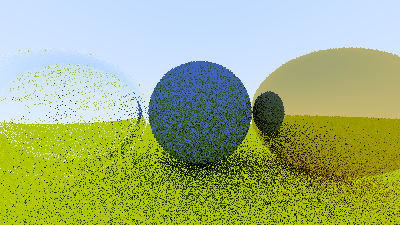

In [6]:
cam.show()